# Notebook 1. Поиск и финализация репрезентативного сабсэмпла

В этом ноутбуке я формирую сокращенный датасет, который дальше будет использоваться для обучения и сравнения рекомендательных моделей.

Работать со всей исходной выборкой напрямую неудобно: в ней десятки миллионов событий и большой каталог треков, поэтому даже базовые последовательные модели обучаются долго. При этом уменьшать данные простым случайным отбором тоже нельзя, потому что можно случайно потерять важные свойства исходной совокупности.

Поэтому здесь я не просто уменьшаю датасет, а отдельно контролирую, чтобы сабсэмпл был похож на исходные данные по основным характеристикам:

1. описываю генеральную совокупность пользователей, треков и событий
2. отбираю пользователей с учетом активности, разнообразия истории, played ratio и доли organic interactions
3. отбираю треки с сохранением распределения по popularity bins
4. проверяю, что финальный таблица событий сохраняет ключевые свойства исходной train-совокупности.

На выходе получается файл final_events.parquet, который дальше используется во всех следующих ноутбуках.


## 1. Импорты и загрузка данных

Сначала загружаю библиотеки и фиксирую random_state, чтобы результаты отбора можно было воспроизвести.

In [1]:
!pip install -q datasets tqdm pyarrow

In [2]:
import os
import json
import time
import random
from typing import Literal

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, DatasetDict, load_dataset

pd.options.display.max_columns = 120
pd.options.display.max_rows = 120
sns.set_theme(style="whitegrid")

import warnings
try:
    from pandas.errors import SettingWithCopyWarning
    warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
except ImportError:
    pass
warnings.simplefilter(action="ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Дальше загружаю основные таблицы Yambda dataset. Для этого ноутбука нужны события прослушиваний, а также признаки is_organic и played_ratio_pct из multi_event.

In [3]:
class YambdaDataset:
    INTERACTIONS = frozenset([
        "likes", "listens", "multi_event", "dislikes", "unlikes", "undislikes"
    ])

    def __init__(
        self,
        dataset_type: Literal["flat", "sequential"] = "flat",
        dataset_size: Literal["50m", "500m", "5b"] = "50m"
    ):
        self.dataset_type = dataset_type
        self.dataset_size = dataset_size

    def interaction(self, event_type: str) -> Dataset:
        if event_type not in self.INTERACTIONS:
            raise ValueError(f"Unknown event_type: {event_type}")
        return self._download(f"{self.dataset_type}/{self.dataset_size}", event_type)

    @staticmethod
    def _download(data_dir: str, file: str) -> Dataset:
        data = load_dataset("yandex/yambda", data_dir=data_dir, data_files=f"{file}.parquet")
        if not isinstance(data, DatasetDict):
            raise TypeError("Expected DatasetDict")
        return data["train"]

In [4]:
# загружаю основные таблицы yambda
dataset = YambdaDataset("flat", "50m")

likes_df = dataset.interaction("likes").to_pandas()
listens_df = dataset.interaction("listens").to_pandas()
dislikes_df = dataset.interaction("dislikes").to_pandas()
unlikes_df = dataset.interaction("unlikes").to_pandas()
undislikes_df = dataset.interaction("undislikes").to_pandas()
multi_event_df = dataset.interaction("multi_event").to_pandas()

data_shapes = pd.DataFrame({
    "dataset": ["likes", "listens", "dislikes", "unlikes", "undislikes", "multi_event"],
    "rows": [
        len(likes_df), len(listens_df), len(dislikes_df),
        len(unlikes_df), len(undislikes_df), len(multi_event_df)
    ],
    "users": [
        likes_df["uid"].nunique(), listens_df["uid"].nunique(), dislikes_df["uid"].nunique(),
        unlikes_df["uid"].nunique(), undislikes_df["uid"].nunique(), multi_event_df["uid"].nunique()
    ],
    "items": [
        likes_df["item_id"].nunique(), listens_df["item_id"].nunique(), dislikes_df["item_id"].nunique(),
        unlikes_df["item_id"].nunique(), undislikes_df["item_id"].nunique(), multi_event_df["item_id"].nunique()
    ],
})

data_shapes

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

flat/50m/likes.parquet:   0%|          | 0.00/7.18M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

...

flat/50m/undislikes.parquet:   0%|          | 0.00/181k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

flat/50m/multi_event.parquet:   0%|          | 0.00/384M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

,dataset,rows,users,items
0,likes,881456,8283,181304
1,listens,46467212,9238,877168
2,dislikes,107776,5951,53413
3,unlikes,312972,6406,117953
4,undislikes,21033,2911,15399
5,multi_event,47790449,10000,934057


## 2. Генеральная совокупность

На первом шаге я смотрю на исходную совокупность событий прослушиваний. Это нужно, чтобы дальше было понятно, с чем сравнивать финальный сабсэмпл. В этом блоке считаются базовые характеристики данных: число событий, пользователей и треков, средняя и медианная длина пользовательской истории, частотность треков и диапазон timestamp. Эти значения дальше используются как ориентир: хороший сабсэмпл не обязан повторять полный датасет по объему, но должен быть похож на него по структуре.

In [5]:
listens_base = listens_df[["uid", "item_id", "timestamp"]].copy()
listens_base["timestamp"] = pd.to_numeric(listens_base["timestamp"], errors="coerce")
listens_base = listens_base.dropna(subset=["timestamp"])
listens_base["timestamp"] = listens_base["timestamp"].astype("int64")
listens_base = (listens_base.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values("timestamp").reset_index(drop=True))

In [6]:
user_hist_len = listens_base.groupby("uid").size()
item_popularity = listens_base.groupby("item_id").size()

population_stats = pd.DataFrame({
    "metric": [
        "listen interactions",
        "unique users",
        "unique tracks",
        "mean interactions per user",
        "median interactions per user",
        "mean listens per track",
        "median listens per track",
        "min timestamp",
        "max timestamp"
    ],
    "value": [
        len(listens_base),
        listens_base["uid"].nunique(),
        listens_base["item_id"].nunique(),
        round(user_hist_len.mean(), 2),
        int(user_hist_len.median()),
        round(item_popularity.mean(), 2),
        int(item_popularity.median()),
        int(listens_base["timestamp"].min()),
        int(listens_base["timestamp"].max())
    ]})

population_stats

,metric,value
0,listen interactions,45879177.00
1,unique users,9238.00
2,unique tracks,877168.00
3,mean interactions per user,4966.35
4,median interactions per user,2975.00
5,mean listens per track,52.30
6,median listens per track,3.00
7,min timestamp,0.00
8,max timestamp,26000000.00


**Вывод:** Исходная совокупность содержит около 45.9 млн событий, 9.2 тыс. пользователей и 877 тыс. уникальных треков. Уже на этом этапе видно, что данные сильно неоднородные: медианный трек встречается всего несколько раз, а среднее число прослушиваний на трек заметно выше. Значит, популярность треков имеет выраженный тяжелый хвост.

Похожая ситуация есть и по пользователям: часть пользователей слушает намного больше среднего. Поэтому простой случайный отбор или top-N отбор здесь не подходят. В финальном сабсэмпле нужно отдельно контролировать и активность пользователей, и распределение популярности треков.

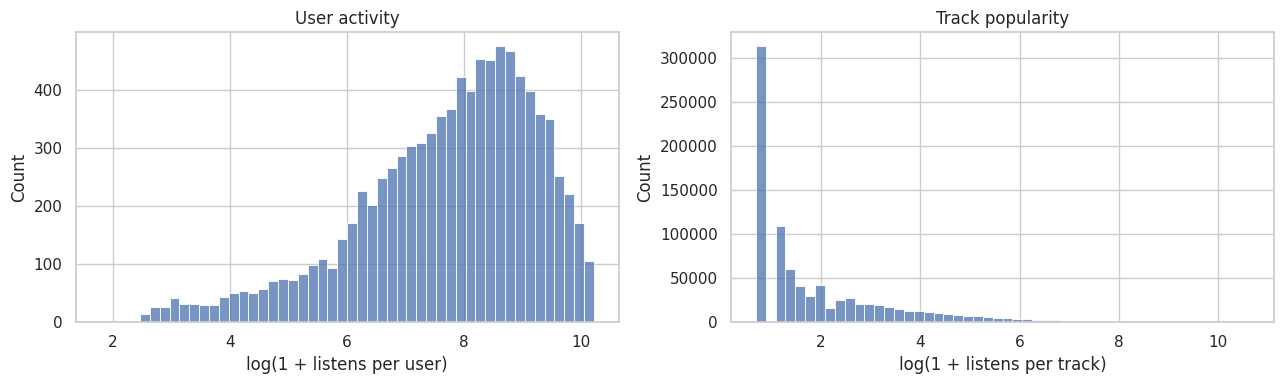

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(np.log1p(user_hist_len), bins=50, ax=axes[0])
axes[0].set_title("User activity")
axes[0].set_xlabel("log(1 + listens per user)")

sns.histplot(np.log1p(item_popularity), bins=50, ax=axes[1])
axes[1].set_title("Track popularity")
axes[1].set_xlabel("log(1 + listens per track)")

plt.tight_layout()
plt.show()

**Вывод:** Распределение пользовательской активности и популярности треков заметно различается по форме. Активность пользователей после логарифмирования выглядит относительно сглаженной, тогда как популярность треков остаётся сильно скошенной: большая часть треков имеет небольшое число прослушиваний, а небольшая доля треков собирает существенно больше событий.

Для отбора это важный момент. Пользователей нужно брать из разных уровней активности, а треки нельзя выбирать только из верхней части распределения. Иначе в данных заранее появится сильный смещение в сторону популярных треков, и дальше будет сложно понять, возникает он из-за модели или уже из-за способа отбора.

## 3. Сплит по времени  как диагностический этап

Перед финальным отбором я делаю простой time split. Здесь он нужен не для итоговой оценки моделей, а только как диагностическая проверка: достаточно ли в данных пользователей и треков, для которых можно строить next-track prediction.

Финальная оценка моделей дальше будет строиться отдельно, уже внутри сохраненного сабсэмпла, по схеме leave-one-out.

In [8]:
# делаю простой time split только как диагностическую проверку
split_ratio = 0.80
split_idx = int(len(listens_base) * split_ratio)
split_time = int(listens_base.iloc[split_idx]["timestamp"])

In [9]:
train_full = listens_base[listens_base["timestamp"] <= split_time].copy()
test_full = listens_base[listens_base["timestamp"] > split_time].copy()
test_next_all = (test_full.sort_values(["uid", "timestamp"]).groupby("uid", as_index=False).first())

In [10]:
train_users = set(train_full["uid"].unique())
train_items = set(train_full["item_id"].unique())
test_next_warm = test_next_all[test_next_all["uid"].isin(train_users) & test_next_all["item_id"].isin(train_items)].copy()

split_stats = pd.DataFrame({
    "metric": [
        "train rows",
        "test rows",
        "train users",
        "test users",
        "test_next users",
        "warm-start valid test users"
    ],
    "value": [
        len(train_full),
        len(test_full),
        train_full["uid"].nunique(),
        test_full["uid"].nunique(),
        test_next_all["uid"].nunique(),
        test_next_warm["uid"].nunique()
    ]})

split_stats

,metric,value
0,train rows,36703351
1,test rows,9175826
2,train users,8669
3,test users,9216
4,test_next users,9216
5,warm-start valid test users,8117


**Вывод:** Диагностический time split подтверждает, что данные подходят для последовательных рекомендаций: у большинства пользователей из тест-периода есть предыдущая история и известные модели треки в train. Поэтому дальше можно переходить к построению сокращенного датасета и leave-one-out постановке. Отмечу, что сам сплит по времени здесь не используется для финальной оценки моделей, а нужен только как проверка структуры данных.

## 4. Поведенческие признаки для отбора пользователей

После предварительной проверки time split я перехожу к построению признаков, по которым будет оцениваться репрезентативность пользователей. Для отбора важно сохранить не только общий размер пользовательской истории, но и характер взаимодействий пользователя с платформой.

В качестве основных признаков используются:

- n_listens - число прослушиваний пользователя
- n_unique_items - число уникальных треков в истории
- mean_played_ratio и median_played_ratio - насколько полно пользователь обычно дослушивает треки
- organic_share - доля органических взаимодействий.

Эти признаки позволяют отобрать пользователей так, чтобы сабсемпл сохранял разные типы поведения, а не состоял только из наиболее активных или наиболее однородных пользователей.

In [11]:
# собираю listen-события с признаками organic и played ratio
sampling_df = multi_event_df.loc[multi_event_df["event_type"] == "listen",["uid", "item_id", "timestamp", "is_organic", "played_ratio_pct"]].copy()
sampling_df["timestamp"] = pd.to_numeric(sampling_df["timestamp"], errors="coerce")
sampling_df = sampling_df.dropna(subset=["timestamp"])
sampling_df["timestamp"] = sampling_df["timestamp"].astype("int64")
sampling_df["is_organic"] = sampling_df["is_organic"].astype(int)
sampling_df["played_ratio_pct"] = pd.to_numeric(sampling_df["played_ratio_pct"], errors="coerce")

In [12]:
sampling_df = (sampling_df.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values("timestamp").reset_index(drop=True))
sampling_train = sampling_df[sampling_df["timestamp"] <= split_time].copy()
sampling_test = sampling_df[sampling_df["timestamp"] > split_time].copy()

print("sampling_train:", sampling_train.shape)
print("sampling_test:", sampling_test.shape)

sampling_train: (36703351, 5)
sampling_test: (9175826, 5)


In [13]:
feedback_reference = {
    "full_organic_share": round(sampling_train["is_organic"].mean(), 4),
    "full_non_organic_share": round(1 - sampling_train["is_organic"].mean(), 4),
    "full_mean_played_ratio": round(sampling_train["played_ratio_pct"].mean(), 4),
    "full_median_played_ratio": round(sampling_train["played_ratio_pct"].median(), 4),
}

pd.DataFrame([feedback_reference])

,full_organic_share,full_non_organic_share,full_mean_played_ratio,full_median_played_ratio
0,0.5117,0.4883,64.9041,100.0


**Вывод:** В трейн-части исходных данных органические и неорганические взаимодействяи представлены почти сбалансированно: доля organic составляет около 51.2%, а non-organic - около 48.8%. Это важно сохранить в финальном сабсэмпле, поскольку дальнейший анализ feedback loop будет напрямую опираться на различие между organic и non-organic взаимодействиями.

Средний played_ratio_pct составляет около 64.9, при этом медианное значение равно 100. Это говорит о том, что значительная часть прослушиваний является полными или почти полными, но одновременно в данных присутствует заметная доля неполных прослушиваний. Поэтому played ratio также включается в контроль репрезентативности пользователей.

In [14]:
overall_org = (sampling_train["is_organic"].value_counts().rename_axis("is_organic").reset_index(name="count"))
overall_org["share"] = overall_org["count"] / overall_org["count"].sum()
overall_org["label"] = overall_org["is_organic"].map({1: "organic", 0: "non-organic"})

In [15]:
user_organic_share = sampling_train.groupby("uid")["is_organic"].mean()
item_organic_share = sampling_train.groupby("item_id")["is_organic"].mean()

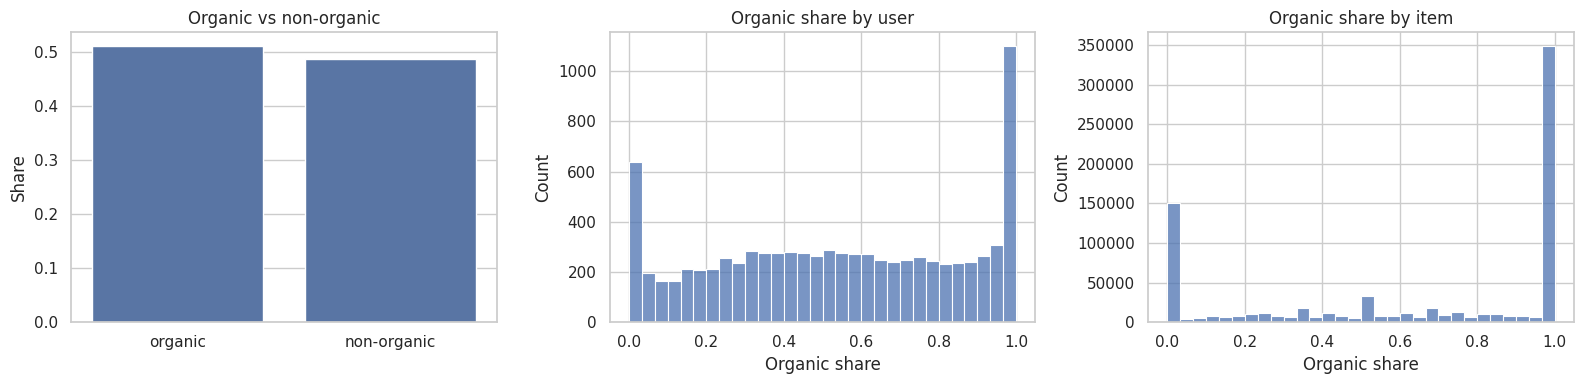

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=overall_org, x="label", y="share", ax=axes[0])
axes[0].set_title("Organic vs non-organic")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share")

sns.histplot(user_organic_share, bins=30, ax=axes[1])
axes[1].set_title("Organic share by user")
axes[1].set_xlabel("Organic share")

sns.histplot(item_organic_share, bins=30, ax=axes[2])
axes[2].set_title("Organic share by item")
axes[2].set_xlabel("Organic share")

plt.tight_layout()
plt.show()

**Вывод:** Хотя общая доля organic и non-organic interactions близка к балансу, на уровне пользователей и треков видна сильная неоднородность. Это важно для исследования feedback loop: если при отборе потерять пользователей с разными значениями organic_share, дальнейшее сравнение organic-only и non-organic-only моделей будет менее надёжным. Поэтому organic_share используется как один из ключевых признаков репрезентативности.

In [17]:
# агрегирую пользовательские признаки для дальнейшей стратификации
user_features = (sampling_train.groupby("uid").agg(
        n_listens=("item_id", "size"),
        n_unique_items=("item_id", "nunique"),
        mean_played_ratio=("played_ratio_pct", "mean"),
        median_played_ratio=("played_ratio_pct", "median"),
        organic_share=("is_organic", "mean"),).reset_index())

user_features["log_n_listens"] = np.log1p(user_features["n_listens"])
user_features.head()

,uid,n_listens,n_unique_items,mean_played_ratio,median_played_ratio,organic_share,log_n_listens
0,100,2739,738,79.462212,100.0,0.364001,7.915713
1,200,262,178,91.068702,100.0,1.000000,5.572154
2,300,561,328,50.700535,44.0,0.992870,6.331502
3,600,580,494,93.741379,100.0,0.017241,6.364751
4,700,8278,2204,64.648224,100.0,0.316260,9.021477


**Вывод:** На основе train-части для каждого пользователя формируется таблица поведенческих признаков. Она используется не для обучения рекомендательных моделей, а только для отбора пользователей в финальный сабсэмпл. Таким образом, сабсэмпл строится с учётом активности, разнообразия истории, полноты прослушивания и доли organic interactions.

## 5. Стратифицированный отбор пользователей

На этом этапе пользователи делятся на группы по нескольким поведенческим признакам: уровню активности, среднему played_ratio_pct и доле organic-взаимодействий. Затем из каждой группы берётся пропорциональная часть пользователей.

Такой подход нужен, чтобы финальная выборка не смещалась только в сторону самых активных пользователей или пользователей с одним типом поведения. В результате в сабсэмпле должны сохраниться разные группы пользователей: более и менее активные, с разной долей organic / non-organic interactions и разной полнотой прослушивания.

In [18]:
# безопасно разбиваю признаки на бины, даже если значений мало или есть повторы
def safe_qcut(series, q=4):
    try:
        return pd.qcut(
            series.rank(method="first"),
            q=q,
            labels=False,
            duplicates="drop"
        ).astype(int)
    except Exception:
        return pd.Series(np.zeros(len(series), dtype=int), index=series.index)


user_features["activity_bin"] = safe_qcut(user_features["log_n_listens"], q=5)
user_features["played_bin"] = safe_qcut(user_features["mean_played_ratio"].fillna(-1), q=4)
user_features["organic_bin"] = safe_qcut(user_features["organic_share"].fillna(-1), q=4)

user_features["user_stratum"] = (
    "a" + user_features["activity_bin"].astype(str) +
    "_p" + user_features["played_bin"].astype(str) +
    "_o" + user_features["organic_bin"].astype(str))


In [19]:
# отбираю пользователей пропорционально из каждой страты
def sample_users_stratified(user_features: pd.DataFrame, n_users: int, random_state: int = 42):
    n_users = min(n_users, len(user_features))
    frac = n_users / len(user_features)

    sampled_parts = []

    for _, group in user_features.groupby("user_stratum"):
        sample_size = int(round(len(group) * frac))
        sample_size = min(max(sample_size, 1), len(group))
        sampled_parts.append(group.sample(n=sample_size, random_state=random_state))

    sampled = pd.concat(sampled_parts, ignore_index=True)

    if len(sampled) > n_users:
        sampled = sampled.sample(n=n_users, random_state=random_state)

    if len(sampled) < n_users:
        missing_n = n_users - len(sampled)
        remaining = user_features[~user_features["uid"].isin(sampled["uid"])]

        if len(remaining) > 0:
            extra = remaining.sample(n=min(missing_n, len(remaining)), random_state=random_state)
            sampled = pd.concat([sampled, extra], ignore_index=True)

    return set(sampled["uid"])

## 6. Отбор треков с matching по popularity bins

После отбора пользователей нужно выбрать набор треков. Простой top-N отбор здесь не подходит: если оставить только самые популярные треки, то смещение в сторону популярных треков будет заложен уже в сам сабсэмпл.

Поэтому треки отбираются через matching по popularity_bin. Сначала по полной train-совокупности строится распределение треков по бинам популярности. Затем среди треков, которые встречаются у выбранных пользователей, выбираются 300 000 треков так, чтобы их распределение по popularity bins было близко к полному каталогу.

In [20]:
# строю бины популярности по полной train-совокупности
def build_full_track_popularity_bins(train_full: pd.DataFrame, n_bins: int = 10):
    full_item_pop = (train_full.groupby("item_id").size().reset_index(name="n_listens"))
    full_item_pop["log_n_listens"] = np.log1p(full_item_pop["n_listens"])
    full_item_pop["popularity_bin"] = pd.qcut(
        full_item_pop["log_n_listens"].rank(method="first"),
        q=n_bins,
        labels=False,
        duplicates="drop").astype(int)

    full_bin_share = (
        full_item_pop["popularity_bin"]
        .value_counts(normalize=True)
        .sort_index()
        .to_dict())

    return full_item_pop, full_bin_share

In [21]:
# выбираю треки так, чтобы сохранить распределение по бинам популярности
def sample_tracks_global_bin_matched(train_for_users: pd.DataFrame,full_item_pop_bins: pd.DataFrame, full_bin_share: dict, n_tracks: int, random_state: int = 42):
    available_tracks = train_for_users["item_id"].drop_duplicates().to_frame()

    available_tracks = available_tracks.merge(full_item_pop_bins[["item_id", "n_listens", "popularity_bin"]], on="item_id", how="inner")
    if len(available_tracks) <= n_tracks:
        return set(available_tracks["item_id"])

    selected_parts = []
    used_ids = set()

    for bin_id, share in full_bin_share.items():
        group = available_tracks[available_tracks["popularity_bin"] == bin_id]

        if group.empty:
            continue

        target_size = int(round(n_tracks * share))
        target_size = min(max(target_size, 1), len(group))

        sampled = group.sample(n=target_size, random_state=random_state)
        selected_parts.append(sampled)
        used_ids.update(sampled["item_id"].tolist())

    selected = pd.concat(selected_parts, ignore_index=True)

    if len(selected) < n_tracks:
        missing_n = n_tracks - len(selected)
        remaining = available_tracks[~available_tracks["item_id"].isin(used_ids)]

        if len(remaining) > 0:
            extra = remaining.sample(n=min(missing_n, len(remaining)), random_state=random_state)
            selected = pd.concat([selected, extra], ignore_index=True)

    if len(selected) > n_tracks:
        selected = selected.sample(n=n_tracks, random_state=random_state)

    return set(selected["item_id"])

In [22]:
# объединяю отбор пользователей и треков в финальный кандидатный сабсэмпл
def build_final_candidate_global_bin_tracks(train_full: pd.DataFrame, sampling_df: pd.DataFrame, user_features: pd.DataFrame, full_item_pop_bins: pd.DataFrame, full_bin_share: dict, n_users: int, n_tracks: int,
    random_state: int = 42):

    selected_users = sample_users_stratified(user_features=user_features, n_users=n_users, random_state=random_state)
    train_for_users = train_full[train_full["uid"].isin(selected_users)].copy()
    selected_tracks = sample_tracks_global_bin_matched(train_for_users=train_for_users, full_item_pop_bins=full_item_pop_bins, full_bin_share=full_bin_share, n_tracks=n_tracks, random_state=random_state)
    final_events = sampling_df[sampling_df["uid"].isin(selected_users) & sampling_df["item_id"].isin(selected_tracks)].copy()

    final_events = (final_events.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values(["uid", "timestamp"]).reset_index(drop=True))

    return final_events, selected_users, selected_tracks


## 7. Финальный сабсэмпл: 5000 пользователей и 300 000 треков

После задания логики отбора формируется финальный таблица событий. Я фиксирую два ограничения: 5000 пользователей и 300 000 треков. Пользователи выбираются стратифицированно по поведенческим признакам, а треки с сохранением распределения по popularity_bin.

Важно, что сохраняются именно события выбранных пользователей по выбранным трекам. То есть финальная таблица остается на уровне uid-item_id-timestamp, потому что в следующих ноутбуках из нее будут строиться последовательности и leave-one-out split.

In [23]:
# фиксирую целевой размер сабсэмпла
N_FINAL_USERS = 5000
N_FINAL_TRACKS = 300000

full_item_pop_bins, full_bin_share = build_full_track_popularity_bins(train_full=train_full, n_bins=10)
final_events, final_users, final_tracks = build_final_candidate_global_bin_tracks(
    train_full=train_full,
    sampling_df=sampling_df,
    user_features=user_features,
    full_item_pop_bins=full_item_pop_bins,
    full_bin_share=full_bin_share,
    n_users=N_FINAL_USERS,
    n_tracks=N_FINAL_TRACKS,
    random_state=RANDOM_STATE)

print("events:", final_events.shape)
print("users:", final_events["uid"].nunique())
print("tracks:", final_events["item_id"].nunique())
print("organic share:", final_events["is_organic"].mean())
print("mean played ratio:", final_events["played_ratio_pct"].mean())

events: (10206636, 5)
users: 4998
tracks: 300000
organic share: 0.5094324907834472
mean played ratio: 64.87937132273552


**Вывод:**  В результате отбора получен финальный сабсэмпл из 4998 пользователей, 300 000 треков и примерно 10.2 млн событий. Доля organic interactions составляет около 0.51, а средний played_ratio_pct - около 64.9. Эти значения близки к характеристикам исходной train-совокупности, поэтому на базовом уровне сабсэмпл сохраняет важные свойства данных.

Небольшое отличие от запрошенных 5000 пользователей связано с тем, что после пересечения выбранных пользователей и выбранных треков часть пользователей может не иметь валидных событий в финальном датасете на уровне событий. Это нормальная ситуация при совместном ограничении и по пользователям, и по трекам.

## 8. Проверка репрезентативности пользователей

Перейдем теперь к проверке выбранной подвыборки на репрезентативность:

In [24]:
# сравниваю одну пользовательскую характеристику в полной выборке и сабсэмпле
def summarize_user_feature(full_df, sub_df, col):
    full_mean = full_df[col].mean()
    sub_mean = sub_df[col].mean()

    return {
        "feature": col,
        "full_mean": round(full_mean, 4),
        "subset_mean": round(sub_mean, 4),
        "full_median": round(full_df[col].median(), 4),
        "subset_median": round(sub_df[col].median(), 4),
        "full_p25": round(full_df[col].quantile(0.25), 4),
        "subset_p25": round(sub_df[col].quantile(0.25), 4),
        "full_p75": round(full_df[col].quantile(0.75), 4),
        "subset_p75": round(sub_df[col].quantile(0.75), 4),
        "relative_mean_diff": round((sub_mean - full_mean) / full_mean, 4)
    }

In [25]:
final_users_features = user_features[user_features["uid"].isin(final_users)].copy()

user_repr_table = pd.DataFrame([
    summarize_user_feature(user_features, final_users_features, "n_listens"),
    summarize_user_feature(user_features, final_users_features, "n_unique_items"),
    summarize_user_feature(user_features, final_users_features, "mean_played_ratio"),
    summarize_user_feature(user_features, final_users_features, "organic_share"),])

user_repr_table

,feature,full_mean,subset_mean,full_median,subset_median,full_p25,subset_p25,full_p75,subset_p75,relative_mean_diff
0,n_listens,4233.8622,4253.3078,2478.0000,2507.5000,670.0000,686.7500,6084.0000,6115.750,0.0046
1,n_unique_items,1240.6418,1239.5192,941.0000,940.5000,357.0000,357.7500,1779.0000,1779.000,-0.0009
2,mean_played_ratio,63.6825,63.5928,66.1902,66.1931,48.1772,48.2241,81.8843,81.885,-0.0014
3,organic_share,0.5421,0.5421,0.5458,0.5458,0.2826,0.2826,0.8299,0.830,-0.0000


**Вывод:**  Выбранные пользователи хорошо воспроизводят основные характеристики полной пользовательской совокупности. Среднее число прослушиваний отличается примерно на 0.5%, число уникальных треков - менее чем на 0.1%, средний played_ratio_pct - примерно на 0.1%, а доля organic-взаимодействий практически совпадает.

Медианы и квартили также близки, поэтому сходство не ограничивается только средними значениями. Это означает, что пользовательский сабсэмпл можно считать репрезентативным по ключевым поведенческим признакам.

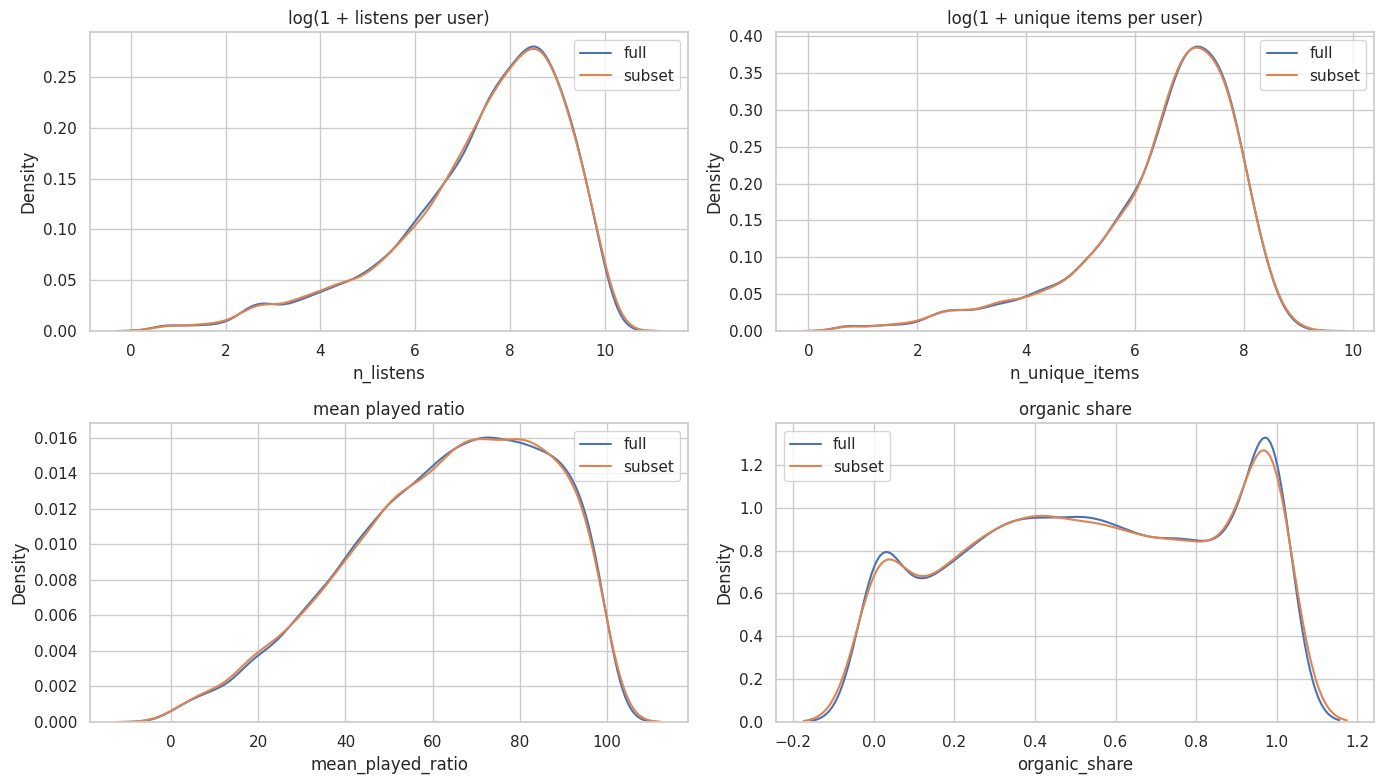

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_specs = [
    ("n_listens", "log(1 + listens per user)", True),
    ("n_unique_items", "log(1 + unique items per user)", True),
    ("mean_played_ratio", "mean played ratio", False),
    ("organic_share", "organic share", False),
]

for ax, (col, title, log_transform) in zip(axes.flatten(), plot_specs):
    full_values = user_features[col].dropna()
    sub_values = final_users_features[col].dropna()

    if log_transform:
        full_values = np.log1p(full_values)
        sub_values = np.log1p(sub_values)

    sns.kdeplot(full_values, ax=ax, label="full", fill=False)
    sns.kdeplot(sub_values, ax=ax, label="subset", fill=False)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

**Вывод:** Графики подтверждают численную проверку: распределения активности, числа уникальных треков, played_ratio_pct и organic_share в сабсэмпле почти совпадают с полной совокупностью. Значит, отбор пользователей не привёл к заметному перекосу в сторону какого-то одного типа поведения.

Это важно для следующих ноутбуков, потому что модели будут обучаться именно на пользовательских последовательностях. Если бы состав пользователей был смещен, качество моделей и дальнейший анализ feedback loop могли бы отражать не свойства алгоритмов, а ошибку на этапе отбора данных.

## 9. Organic / non-organic и played ratio

После проверки пользовательских признаков отдельно сравниваю структуру взаимодействий в полной train-совокупности и в финальном сабсэмпле. Здесь важно сохранить две характеристики: долю organic / non-organic interactions и распределение played_ratio_pct.

Эти признаки важны для дальнейшей части работы, потому что feedback loop будет анализироваться через различие organic и non-organic взаимодействий, а played_ratio_pct отражает интенсивность или полноту прослушивания.

In [27]:
full_organic_share = sampling_train["is_organic"].mean()
subset_organic_share = final_events["is_organic"].mean()

In [28]:
organic_repr_table = pd.DataFrame({
    "metric": [
        "organic share",
        "non-organic share",
        "mean played ratio",
        "median played ratio",
        "interactions"
    ],
    "full_data": [
        round(full_organic_share, 4),
        round(1 - full_organic_share, 4),
        round(sampling_train["played_ratio_pct"].mean(), 4),
        round(sampling_train["played_ratio_pct"].median(), 4),
        len(sampling_train)
    ],
    "final_subset": [
        round(subset_organic_share, 4),
        round(1 - subset_organic_share, 4),
        round(final_events["played_ratio_pct"].mean(), 4),
        round(final_events["played_ratio_pct"].median(), 4),
        len(final_events)
    ]
})

organic_repr_table["relative_diff"] = (
    (organic_repr_table["final_subset"] - organic_repr_table["full_data"]) /
    organic_repr_table["full_data"]
).replace([np.inf, -np.inf], np.nan).round(4)

organic_repr_table

,metric,full_data,final_subset,relative_diff
0,organic share,5.117000e-01,5.094000e-01,-0.0045
1,non-organic share,4.883000e-01,4.906000e-01,0.0047
2,mean played ratio,6.490410e+01,6.487940e+01,-0.0004
3,median played ratio,1.000000e+02,1.000000e+02,0.0000
4,interactions,3.670335e+07,1.020664e+07,-0.7219


**Вывод:**  Финальный сабсэмпл хорошо сохраняет структуру organic / non-organic interactions и played_ratio_pct. Доля organic interactions отличается от полной train-совокупности менее чем на 0.5 п.п., средний played_ratio_pct практически совпадает, а медианное значение остаётся равным 100.

Число событий в сабсэмпле ожидаемо меньше, чем в полной совокупности, так как здесь уже фиксируются ограничения на 5000 пользователей и 300 000 треков. Это не является проблемой: цель отбора - не сохранить весь объём данных, а получить меньший event-level dataset с похожими ключевыми характеристиками.

## 10. Репрезентативность треков по частотности

На этом этапе проверяется, насколько выбранные 300 000 треков сохраняют распределение популярности полного каталога. Для этого треки разбиваются на 10 popularity_bin по числу прослушиваний в train-совокупности, после чего сравнивается доля треков в каждом бине для полного каталога и выбранного набора.

Важно различать два уровня анализа: здесь сравнивается именно распределение треков, а не распределение событий. Один трек может встречаться в данных один раз, а другой - тысячи раз, поэтому равномерное распределение треков по popularity bins не означает равномерное распределение прослушиваний.

In [29]:
# проверяю распределение выбранных треков по popularity bins
selected_bins = full_item_pop_bins[full_item_pop_bins["item_id"].isin(final_tracks)].copy()
full_bin_share_df = (full_item_pop_bins["popularity_bin"].value_counts(normalize=True).sort_index().reset_index())
full_bin_share_df.columns = ["popularity_bin", "full_share"]
subset_bin_share_df = (selected_bins["popularity_bin"].value_counts(normalize=True).sort_index().reset_index())
subset_bin_share_df.columns = ["popularity_bin", "subset_share"]

In [30]:
popularity_bin_comparison = full_bin_share_df.merge(subset_bin_share_df, on="popularity_bin", how="left")
popularity_bin_comparison["subset_share"] = popularity_bin_comparison["subset_share"].fillna(0)
popularity_bin_comparison["diff"] = (popularity_bin_comparison["subset_share"] - popularity_bin_comparison["full_share"]).round(4)
popularity_bin_comparison["abs_diff"] = popularity_bin_comparison["diff"].abs()

popularity_distance = popularity_bin_comparison["abs_diff"].sum() / 2

print("Popularity distribution distance:", round(popularity_distance, 4))
popularity_bin_comparison

Popularity distribution distance: 0.0


,popularity_bin,full_share,subset_share,diff,abs_diff
0,0,0.1,0.1,0.0,0.0
1,1,0.1,0.1,0.0,0.0
2,2,0.1,0.1,0.0,0.0
3,3,0.1,0.1,0.0,0.0
4,4,0.1,0.1,0.0,0.0
5,5,0.1,0.1,0.0,0.0
6,6,0.1,0.1,0.0,0.0
7,7,0.1,0.1,0.0,0.0
8,8,0.1,0.1,0.0,0.0
9,9,0.1,0.1,0.0,0.0


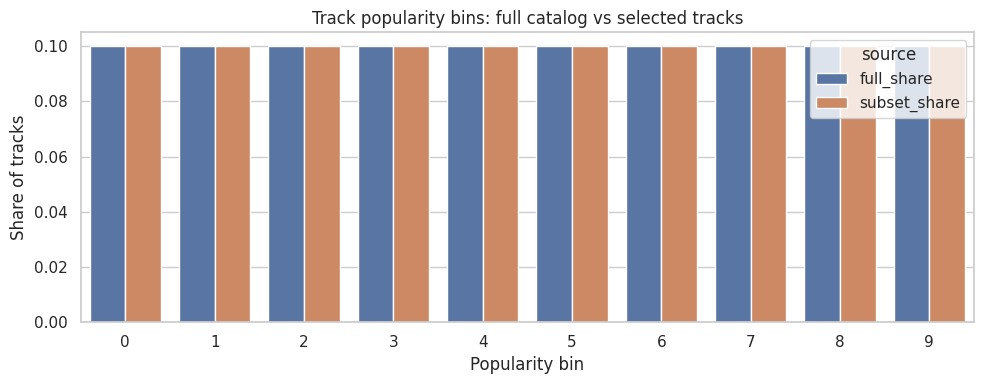

In [31]:
plot_bins = popularity_bin_comparison.melt(id_vars="popularity_bin", value_vars=["full_share", "subset_share"], var_name="source", value_name="share")

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_bins, x="popularity_bin", y="share", hue="source")
plt.title("Track popularity bins: full catalog vs selected tracks")
plt.xlabel("Popularity bin")
plt.ylabel("Share of tracks")
plt.tight_layout()
plt.show()

In [32]:
full_item_popularity = (train_full.groupby("item_id").size().reset_index(name="full_n_listens"))
selected_item_popularity = full_item_popularity[full_item_popularity["item_id"].isin(final_tracks)].copy()

In [33]:
track_popularity_summary = pd.DataFrame({
    "metric": [
        "items",
        "mean popularity",
        "median popularity",
        "p25 popularity",
        "p75 popularity",
        "p90 popularity",
        "p95 popularity",
        "max popularity"
    ],
    "full_catalog": [
        full_item_popularity["item_id"].nunique(),
        round(full_item_popularity["full_n_listens"].mean(), 4),
        round(full_item_popularity["full_n_listens"].median(), 4),
        round(full_item_popularity["full_n_listens"].quantile(0.25), 4),
        round(full_item_popularity["full_n_listens"].quantile(0.75), 4),
        round(full_item_popularity["full_n_listens"].quantile(0.90), 4),
        round(full_item_popularity["full_n_listens"].quantile(0.95), 4),
        round(full_item_popularity["full_n_listens"].max(), 4),
    ],
    "selected_tracks_by_full_popularity": [
        selected_item_popularity["item_id"].nunique(),
        round(selected_item_popularity["full_n_listens"].mean(), 4),
        round(selected_item_popularity["full_n_listens"].median(), 4),
        round(selected_item_popularity["full_n_listens"].quantile(0.25), 4),
        round(selected_item_popularity["full_n_listens"].quantile(0.75), 4),
        round(selected_item_popularity["full_n_listens"].quantile(0.90), 4),
        round(selected_item_popularity["full_n_listens"].quantile(0.95), 4),
        round(selected_item_popularity["full_n_listens"].max(), 4),
    ]
})

track_popularity_summary

,metric,full_catalog,selected_tracks_by_full_popularity
0,items,775490.0000,300000.0000
1,mean popularity,47.3292,47.1801
2,median popularity,3.0000,3.0000
3,p25 popularity,1.0000,1.0000
4,p75 popularity,12.0000,12.0000
5,p90 popularity,59.0000,59.0000
6,p95 popularity,156.0000,156.0000
7,max popularity,34280.0000,34280.0000


**Вывод:** Выбранные 300 000 треков полностью повторяют распределение полного каталога по popularity_bin: в каждом бине сохраняется по 10% треков, а popularity distribution distance равна 0. Это подтверждает, что треки не были отобраны только из верхней части распределения популярности. При этом важно, что здесь проверяется именно распределение треков, а не событий: прослушивания всё равно могут быть сильнее сконцентрированы на популярных треках.

## 11. Проверка применимости leave-one-out

Перед переходом к моделям нужно проверить, можно ли на этом сабсэмпле строить leave-one-out split. Для такой схемы у пользователя должно быть минимум несколько событий: часть истории остается в train, предпоследнее событие используется как validation target, а последнее - как test target.

In [34]:
# проверяю, хватает ли истории для leave-one-out split
user_lengths = final_events.groupby("uid").size()

loo_feasibility = pd.DataFrame({
    "metric": [
        "users total",
        "users with >= 3 events",
        "users with >= 5 events",
        "mean events per user",
        "median events per user",
        "min events per user",
        "max events per user"
    ],
    "value": [
        final_events["uid"].nunique(),
        int((user_lengths >= 3).sum()),
        int((user_lengths >= 5).sum()),
        round(user_lengths.mean(), 2),
        round(user_lengths.median(), 2),
        int(user_lengths.min()),
        int(user_lengths.max())
    ]
})

loo_feasibility

,metric,value
0,users total,4998.00
1,users with >= 3 events,4993.00
2,users with >= 5 events,4979.00
3,mean events per user,2042.14
4,median events per user,1281.00
5,min events per user,1.00
6,max events per user,11432.00


**Вывод:** leave-one-out split можно применять к выбранному сабсэмплу. Из 4998 пользователей 4993 имеют минимум 3 события, то есть почти все пользователи могут быть использованы в постановке train / validation / test.

Это означает, что финальный датасет подходит для next-track prediction: у пользователей есть достаточно истории, чтобы построить контекст и выделить отдельные target-события для оценки моделей.

## 12. Итоговое обоснование выбора

В этом блоке я просто собираю основные проверки в одну таблицу. Она нужна как краткое обоснование того, почему именно этот сабсэмпл дальше используется в моделях.

In [35]:
final_summary = pd.DataFrame({
    "metric": [
        "events",
        "users",
        "tracks",
        "organic share",
        "mean played ratio",
        "popularity distance",
        "users with >= 3 events"
    ],
    "value": [
        len(final_events),
        final_events["uid"].nunique(),
        final_events["item_id"].nunique(),
        round(final_events["is_organic"].mean(), 4),
        round(final_events["played_ratio_pct"].mean(), 4),
        round(popularity_distance, 4),
        int((user_lengths >= 3).sum())
    ]
})

final_summary

,metric,value
0,events,1.020664e+07
1,users,4.998000e+03
2,tracks,3.000000e+05
3,organic share,5.094000e-01
4,mean played ratio,6.487940e+01
5,popularity distance,0.000000e+00
6,users with >= 3 events,4.993000e+03


In [36]:
# фиксирую основные критерии, по которым проверялся отбор
final_justification = pd.DataFrame({
    "criterion": [
        "User activity",
        "User item diversity",
        "Played ratio",
        "Organic share",
        "Track frequency profile",
        "Leave-one-out feasibility",
        "Computational feasibility"
    ],
    "evidence": [
        f"relative mean difference in n_listens = {user_repr_table.loc[user_repr_table['feature'] == 'n_listens', 'relative_mean_diff'].iloc[0]}",
        f"relative mean difference in n_unique_items = {user_repr_table.loc[user_repr_table['feature'] == 'n_unique_items', 'relative_mean_diff'].iloc[0]}",
        f"subset mean played ratio = {organic_repr_table.loc[organic_repr_table['metric'] == 'mean played ratio', 'final_subset'].iloc[0]}, full = {organic_repr_table.loc[organic_repr_table['metric'] == 'mean played ratio', 'full_data'].iloc[0]}",
        f"subset organic share = {round(subset_organic_share, 4)}, full = {round(full_organic_share, 4)}",
        f"popularity bin distance = {round(popularity_distance, 4)}",
        f"users with at least 3 events = {int((user_lengths >= 3).sum())}",
        "timing tests for GRU/SASRec were checked on candidate subsets"
    ]
})

final_justification

,criterion,evidence
0,User activity,relative mean difference in n_listens = 0.0046
1,User item diversity,relative mean difference in n_unique_items = -...
2,Played ratio,"subset mean played ratio = 64.8794, full = 64...."
3,Organic share,"subset organic share = 0.5094, full = 0.5117"
4,Track frequency profile,popularity bin distance = 0.0
5,Leave-one-out feasibility,users with at least 3 events = 4993
6,Computational feasibility,timing tests for GRU/SASRec were checked on ca...


## 13. Сохранение финального сабсэмпла

Сохраним теперь только сабсэмпл на уровне событий и списки выбранных пользователей/треков. Train/validation/test split здесь не фиксируется: он будет построен в следующем ноутбуке по leave-one-out.

In [37]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import pandas as pd

output_dir = "/content/drive/MyDrive/Курсовая/final_subsample"
os.makedirs(output_dir, exist_ok=True)

final_events.to_parquet(f"{output_dir}/final_events.parquet", index=False)

Mounted at /content/drive
